# Pycistopic

In [2]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

In [3]:
import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

'1.0.2.dev7+gda26088'

In [4]:
# Project directory
projDir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus/'
# Output directory
outDir = projDir + 'pycistopic/'
import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
    
work_dir = outDir

In [4]:
# counts matrix needs to be transformed
count_matrix = sc.io.mmread(projDir + 'atac.mtx')
count_matrix_pd = pd.DataFrame(count_matrix.toarray()).T # transpose to be removed?

In [5]:
cluster_metadata = pd.read_csv(projDir + 'cluster_metadata.txt')
peaks = pd.read_csv(projDir + 'peaks.txt')

In [6]:
count_matrix_pd.columns =  peaks['x'].tolist()
count_matrix_pd.index = cluster_metadata['cluster'].tolist()

In [7]:
count_matrix_pd = count_matrix_pd.T
count_matrix_pd.columns = count_matrix_pd.columns.astype(str)

## 1. Creating a cisTopic object

In [9]:
# Create cisTopic object
from pycisTopic.cistopic_class import *
# count_matrix=pd.read_csv(projDir+'epiblast_blood_atac_mtx.tsv', sep='\t')
# count_matrix = count_matrix.set_index('cell')

#path_to_blacklist='/staging/leuven/stg_00002/lcb/cbravo/Multiomics_pipeline/pycisTopic/blacklist/hg19-blacklist.v2.bed'
cistopic_obj = create_cistopic_object(fragment_matrix=count_matrix_pd) #, path_to_blacklist=path_to_blacklist)
# Adding cell information
cluster_metadata = cluster_metadata.set_index('cluster')
cistopic_obj.add_cell_data(cluster_metadata)

2024-10-30 10:21:50,119 cisTopic     INFO     Converting fragment matrix to sparse matrix
2024-10-30 10:21:55,917 cisTopic     INFO     Creating CistopicObject
2024-10-30 10:21:59,436 cisTopic     INFO     Done!


In [10]:
print(cistopic_obj)

CistopicObject from project cisTopic with n_cells × n_regions = 1302 × 234908


In [11]:
# Save without doublets
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 2. Run models

In [12]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [37]:
# #path_to_mallet_binary="/rds/project/rds-SDzz0CATGms/users/bt392/miniconda3/envs/scenicplus/bin/mallet"
# path_to_mallet_binary="/rds/project/rds-SDzz0CATGms/users/bt392/software/github/Mallet/bin/mallet"
# os.environ['MALLET_MEMORY'] = '100G'
# # Run models
# models= run_cgs_models_mallet(path_to_mallet_binary, #run_cgs_models(
#                     cistopic_obj,
#                     n_topics=[2,3], #[2,4,10,15,25,35]
#                     n_cpu=30,
#                     n_iter=500,
#                     random_state=555,
#                     alpha=50,
#                     alpha_by_topic=True,
#                     eta=0.1,
#                     eta_by_topic=False,
#                     tmp_path  =tmpDir, #Use SCRATCH if many models or big data set
#                     save_path=None)

# # Save
# import pickle
# with open(outDir+'models_500.pkl', 'wb') as f:
#   pickle.dump(models, f)

2024-10-29 15:27:48,144 cisTopic     INFO     Formatting input to corpus
2024-10-29 15:27:49,692 gensim.corpora.dictionary INFO     adding document #0 to Dictionary<0 unique tokens: []>
2024-10-29 15:29:09,245 gensim.corpora.dictionary INFO     built Dictionary<234908 unique tokens: ['0', '1', '2', '3', '4']...> from 1302 documents (total 167437244 corpus positions)
2024-10-29 15:29:09,246 cisTopic     INFO     Running model with 2 topics
2024-10-29 15:29:09,255 LDAMalletWrapper INFO     Serializing temporary corpus to /home/bt392/ry/corpus.txt
2024-10-29 15:33:51,493 LDAMalletWrapper INFO     Converting temporary corpus to MALLET format with /rds/project/rds-SDzz0CATGms/users/bt392/software/github/Mallet/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /home/bt392/ry/corpus.txt --output /home/bt392/ry/corpus.mallet
2024-10-29 15:34:32,373 LDAMalletWrapper INFO     Training MALLET LDA with /rds/project/rds-SDzz0CATGms/users/bt392/sof

In [13]:
%%bash
sbatch
#!/bin/bash
#SBATCH -p icelake-himem #skylake-himem #icelake #skylake #-himem #cclake
#SBATCH -A gottgens-sl2-cpu
### Modify this according to your Ray workload.
#SBATCH --nodes=1
#SBATCH --exclusive
#SBATCH --tasks-per-node=1
#SBATCH --time 12:00:00
### Modify this according to your Ray workload.
#SBATCH --cpus-per-task=30
#SBATCH --mem-per-cpu=5GB
#SBATCH --gpus-per-task=0

python /rds/project/rds-SDzz0CATGms/users/bt392/software/github/pycisTopic/model_scripts/runModels_lda_mallet.py \
        -i /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus/pycistopic/cisTopicObject.pkl \
        -o /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus/pycistopic/models_500_mallet.pkl \
        -nt 2,4,10,15,25,35 \
        -c 30 \
        -it 500 \
        -a 50 \
        -abt True \
        -e 0.1 \
        -ebt False \
        -sp /home/bt392/ry/ \
        -s 555 \
        -td /home/bt392/ry

Submitted batch job 63284773


## 3. Model selection

In [14]:
# Load cisTopic object
import pickle
infile = open(outDir + 'models_500_mallet.pkl', 'rb')
models = pickle.load(infile)
infile.close()

In [15]:
models

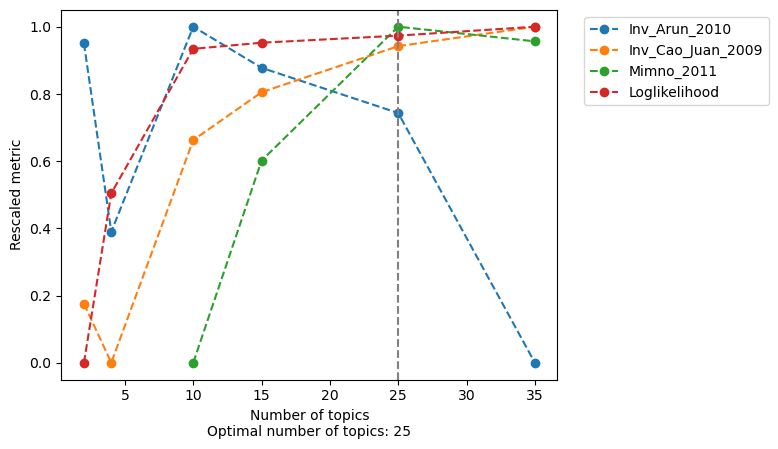

In [17]:
#os.mkdir(outDir+'models')
model=evaluate_models(models,
                     select_model=None,
                     return_model=True,
                     metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011','loglikelihood'],
                     plot_metrics=False,
                     save= outDir + 'models/model_selection.pdf')

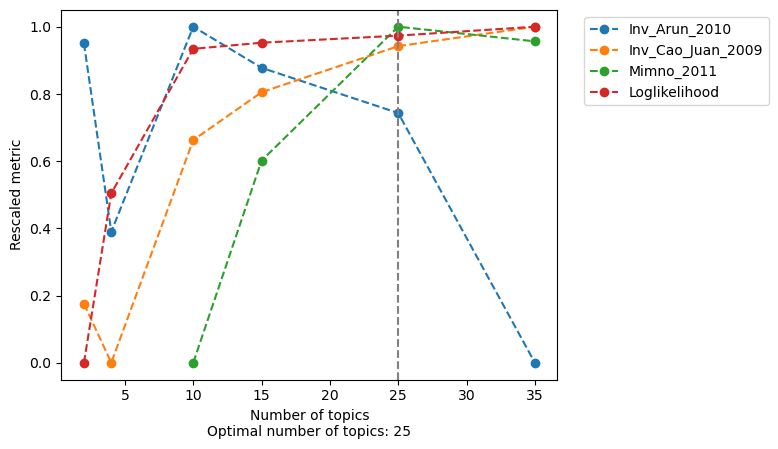

In [19]:
from pycisTopic.lda_models import *
model = evaluate_models(models,
                       select_model=25,
                       return_model=True,
                       metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011', 'loglikelihood'],
                       plot_metrics=False)

In [21]:
cistopic_obj.add_LDA_model(model)
pickle.dump(cistopic_obj,
            open(os.path.join(work_dir, 'cisTopicObject.pkl'), 'wb'))

In [ ]:
# # Save
# with open(outDir + 'epiblast_blood_cisTopicObject.pkl', 'wb') as f:
#   pickle.dump(cistopic_obj, f)

## 4. Clustering & Visualisation

In [22]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [23]:
from pycisTopic.clust_vis import *
find_clusters(cistopic_obj,
                 target  = 'cell',
                 k = 10,
                 res = [0.6],
                 prefix = 'pycisTopic_',
                 scale = True,
                 split_pattern = '-')

2024-10-30 14:46:26,007 cisTopic     INFO     Finding neighbours


In [24]:
run_umap(cistopic_obj,
                 target  = 'cell', scale=True)

2024-10-30 14:46:26,795 cisTopic     INFO     Running UMAP


In [25]:
run_tsne(cistopic_obj,
                 target  = 'cell', scale=True)

2024-10-30 14:46:32,942 cisTopic     INFO     Running TSNE


In [36]:
cluster_metadata = pd.read_csv(projDir + 'cluster_metadata.txt')

In [41]:
cistopic_obj.cell_data['celltype'] = cluster_metadata['celltype'].tolist()

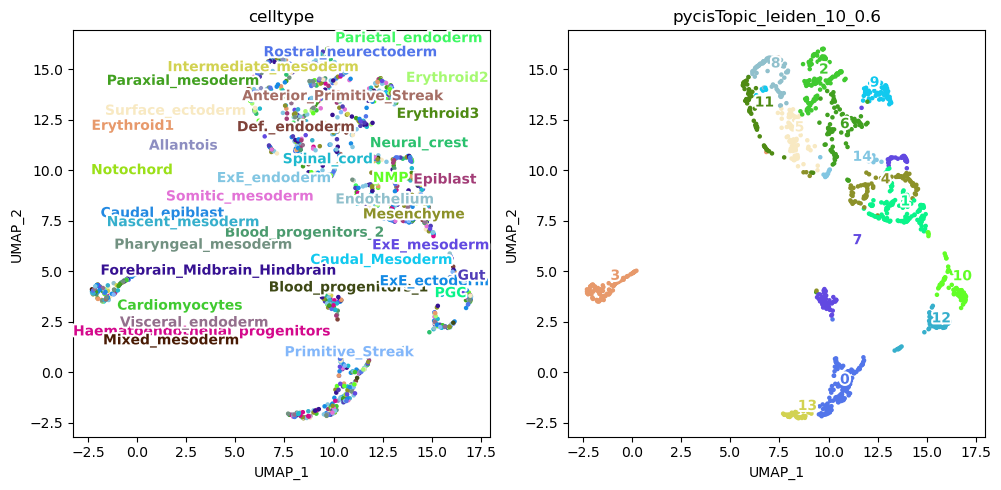

In [44]:
os.mkdir(outDir+'/visualization')
plot_metadata(cistopic_obj,
                 reduction_name='UMAP',
                 variables=['celltype', 'pycisTopic_leiden_10_0.6'], # Labels from RNA and new clusters
                 target='cell', num_columns=3,
                 text_size=10,
                 dot_size=5,
                 figsize=(15,5),
                 save= outDir + 'visualization/dimensionality_reduction_label.pdf')

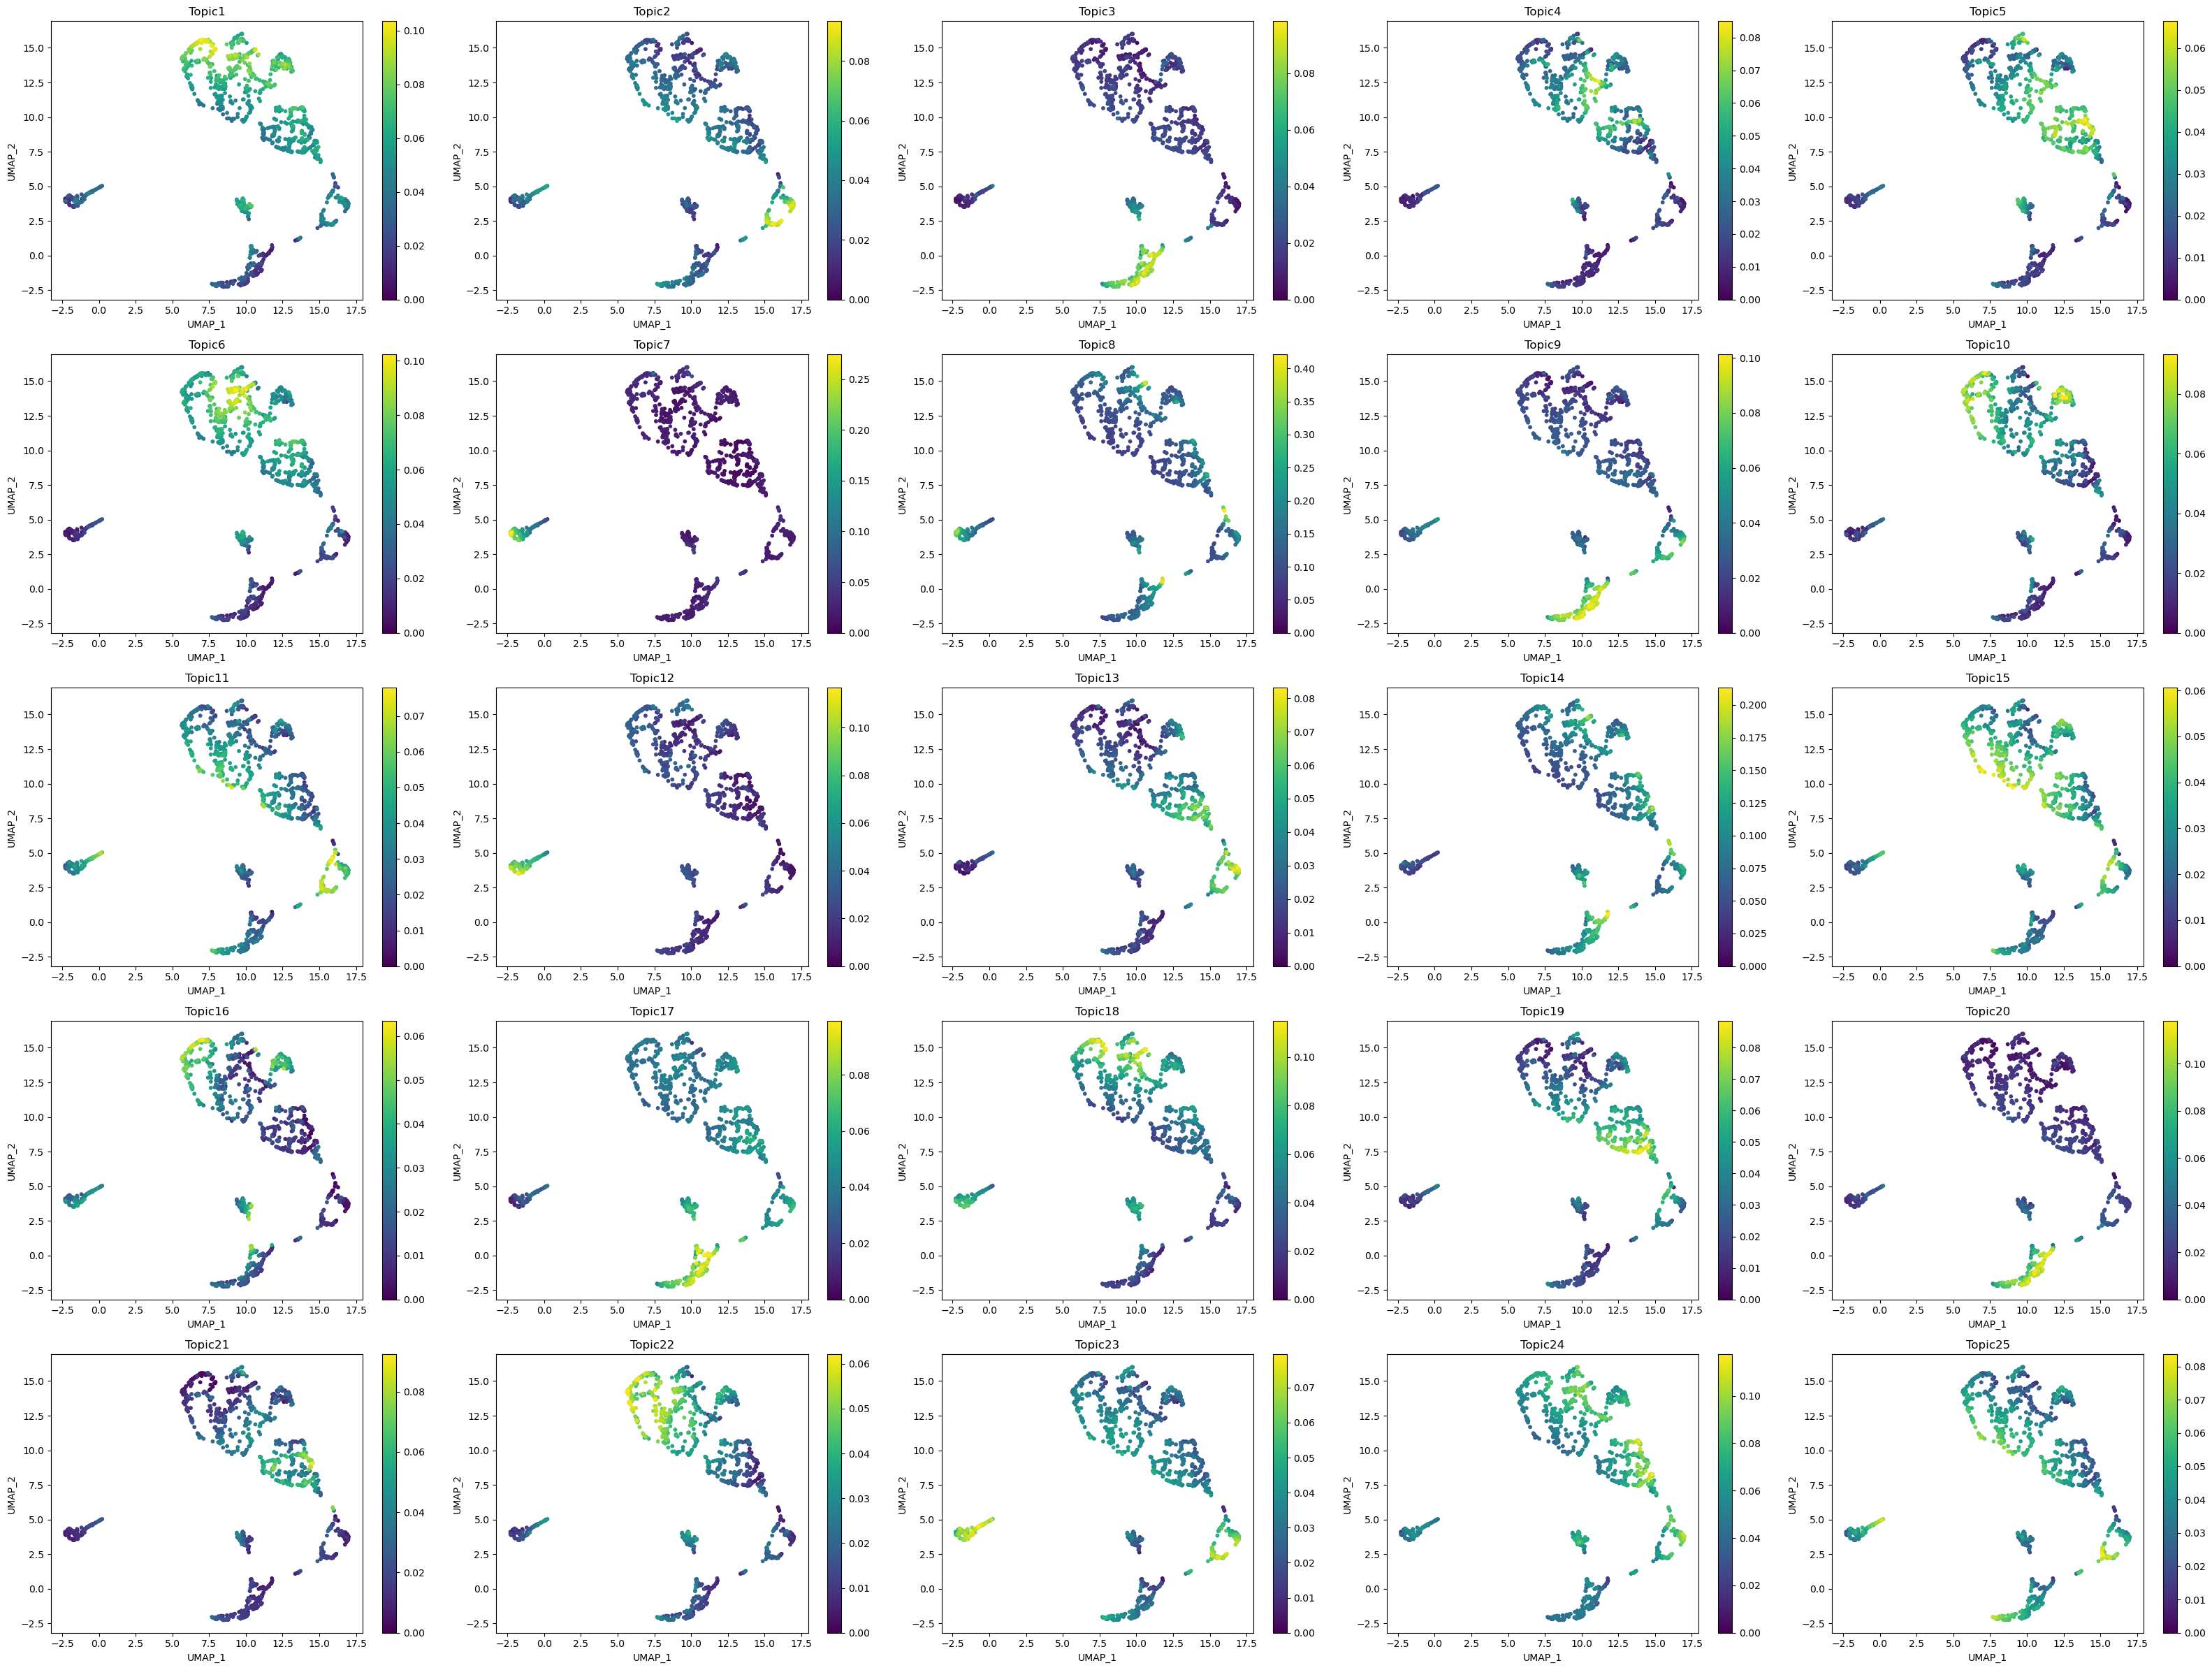

In [50]:
plot_topic(cistopic_obj,
            reduction_name = 'UMAP',
            target = 'cell',
            num_columns=5,
            save= outDir + 'visualization/dimensionality_reduction_topic_contr.pdf')

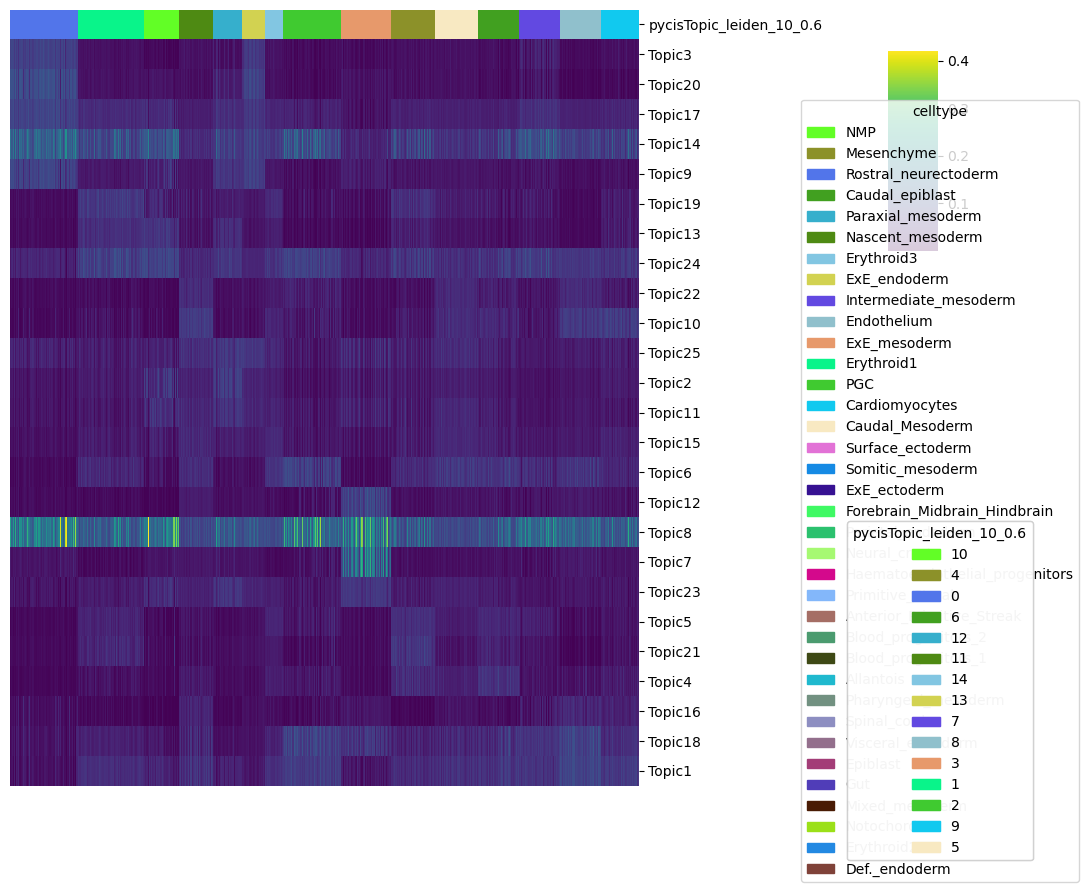

In [77]:
cell_topic_heatmap(cistopic_obj,
                     variables = ['pycisTopic_leiden_10_0.6'],
                     scale = False,
                     legend_loc_x = 1.05,
                     legend_loc_y = -1.2,
                     legend_dist_y = -1,
                     figsize=(10,10),
                     save = outDir + 'visualization/heatmap_topic_contr.pdf')

In [53]:
# Save
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 5. Topic binarization & qc

In [54]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

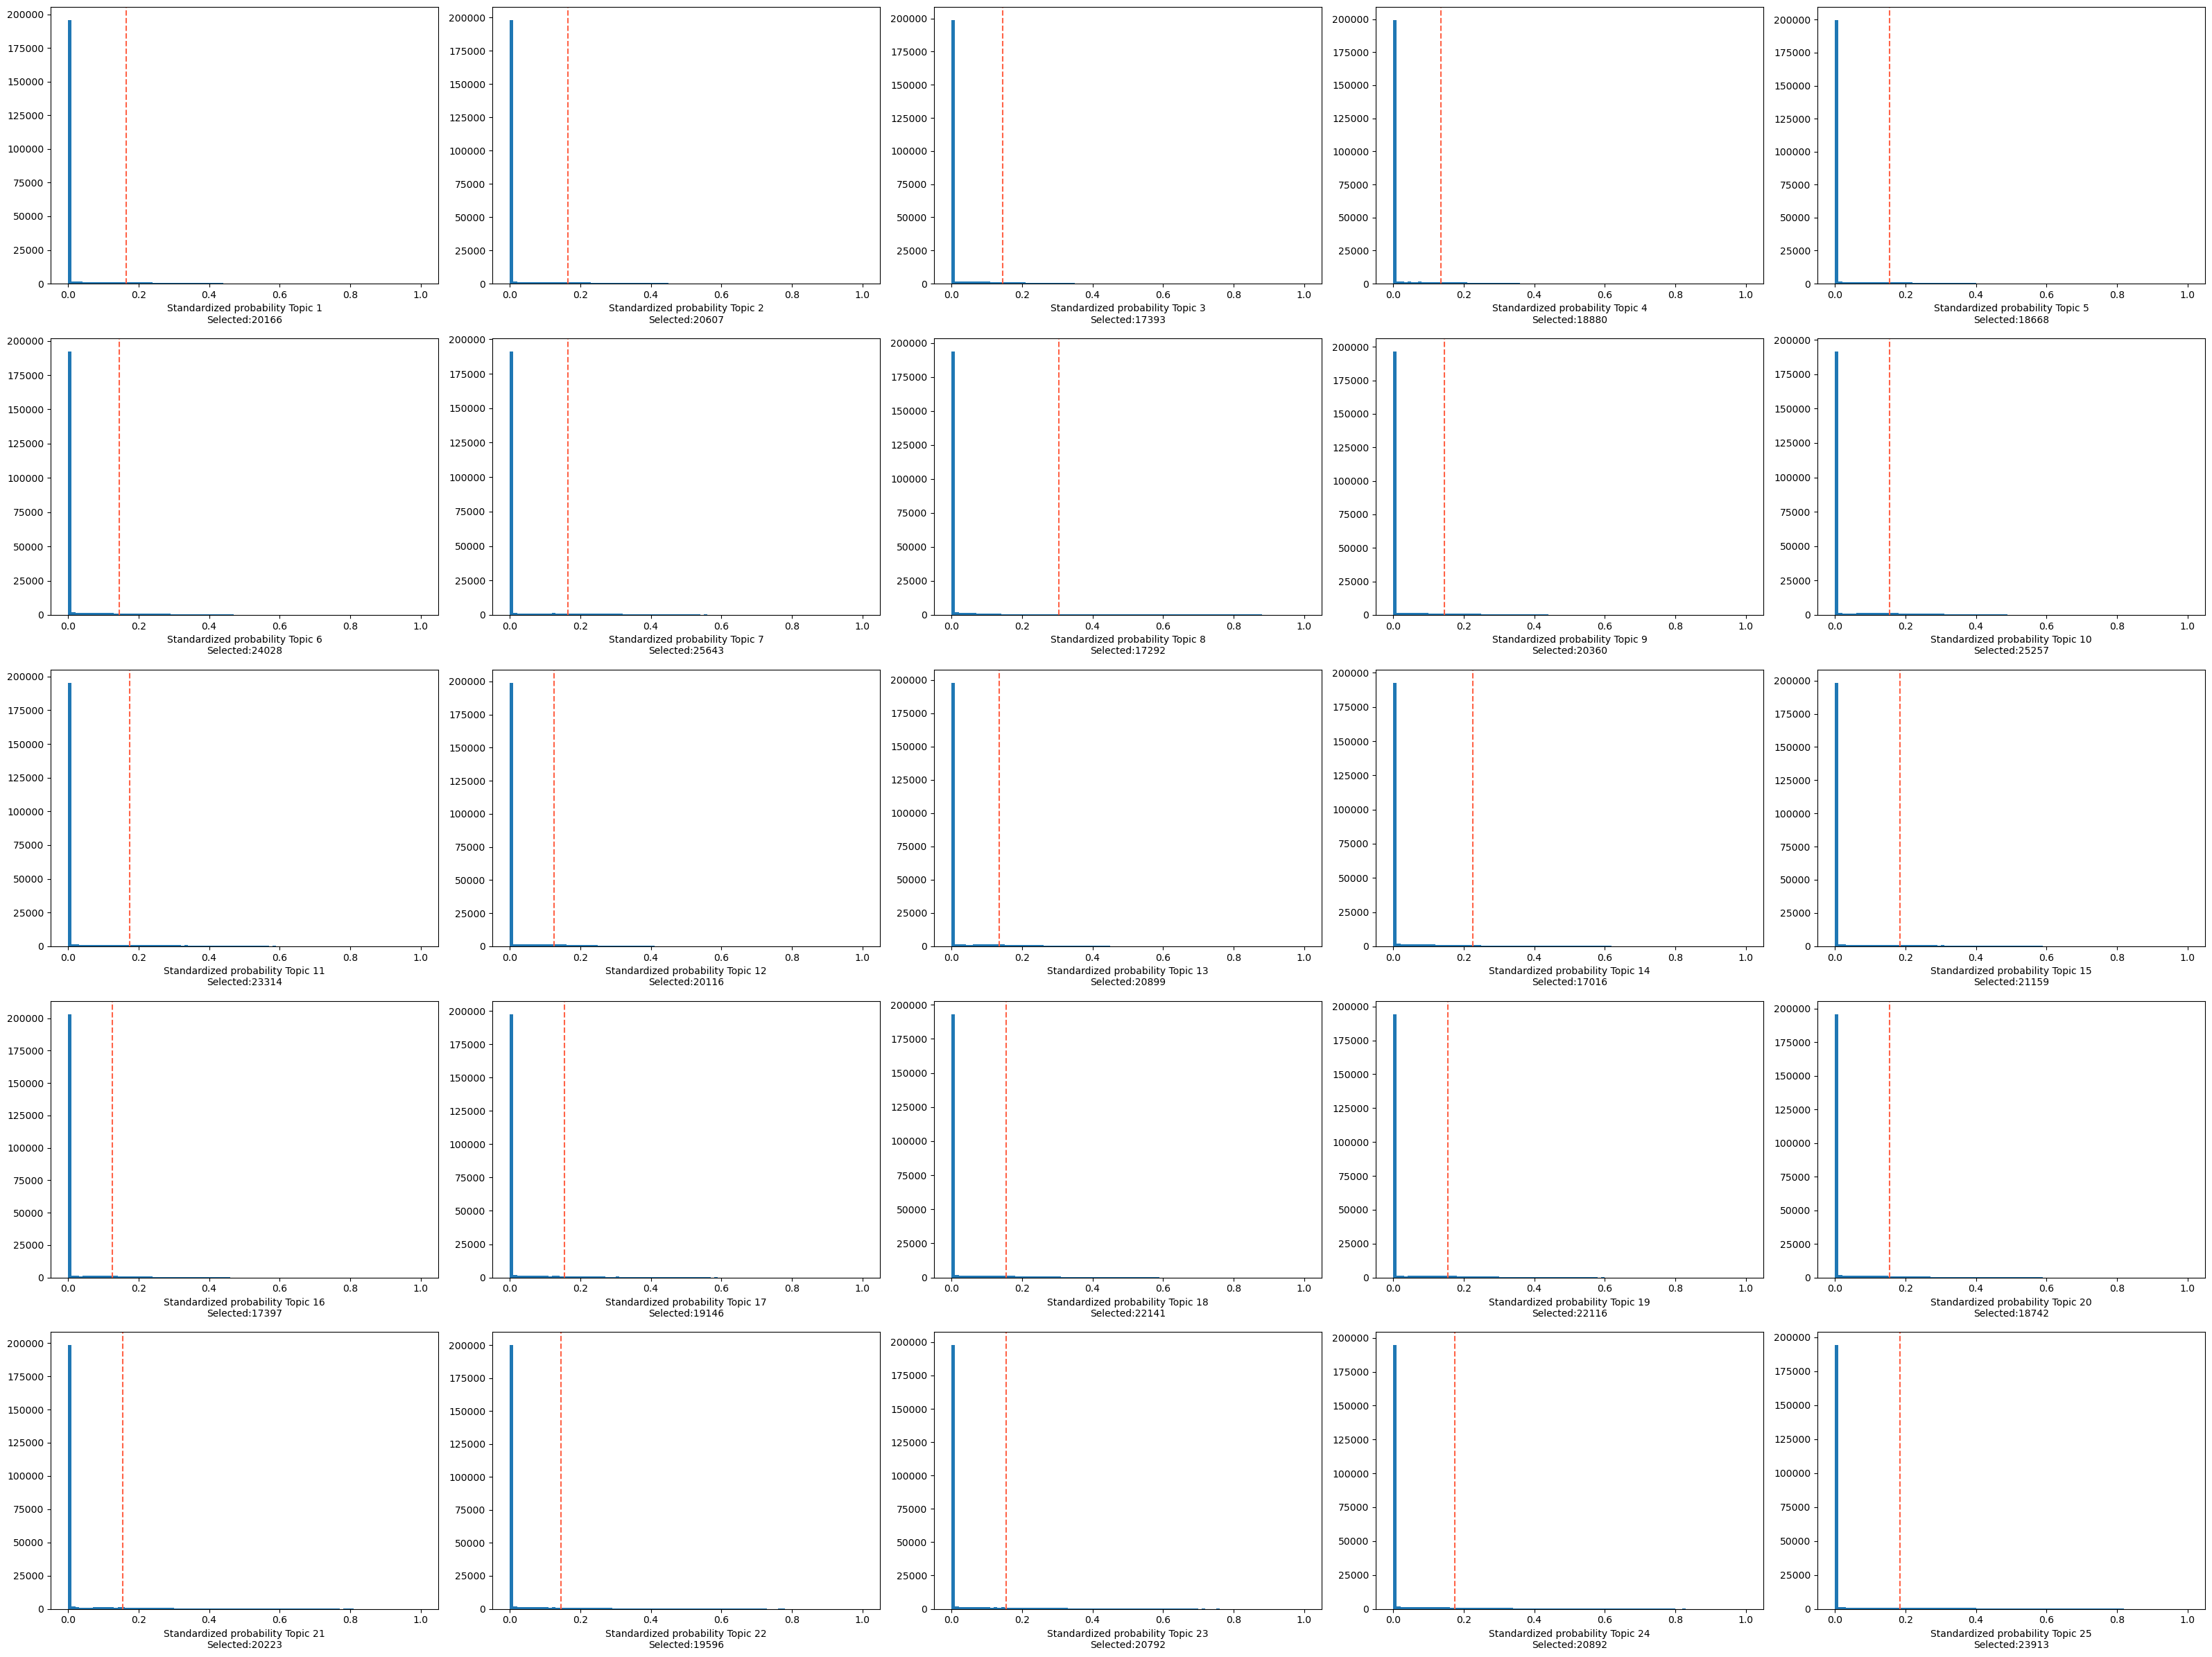

In [57]:
os.mkdir(outDir+'topic_binarization')
from pycisTopic.topic_binarization import *
region_bin_topics = binarize_topics(cistopic_obj, method='otsu', ntop=3000, plot=True, num_columns=5, save= outDir + 'topic_binarization/otsu.pdf')

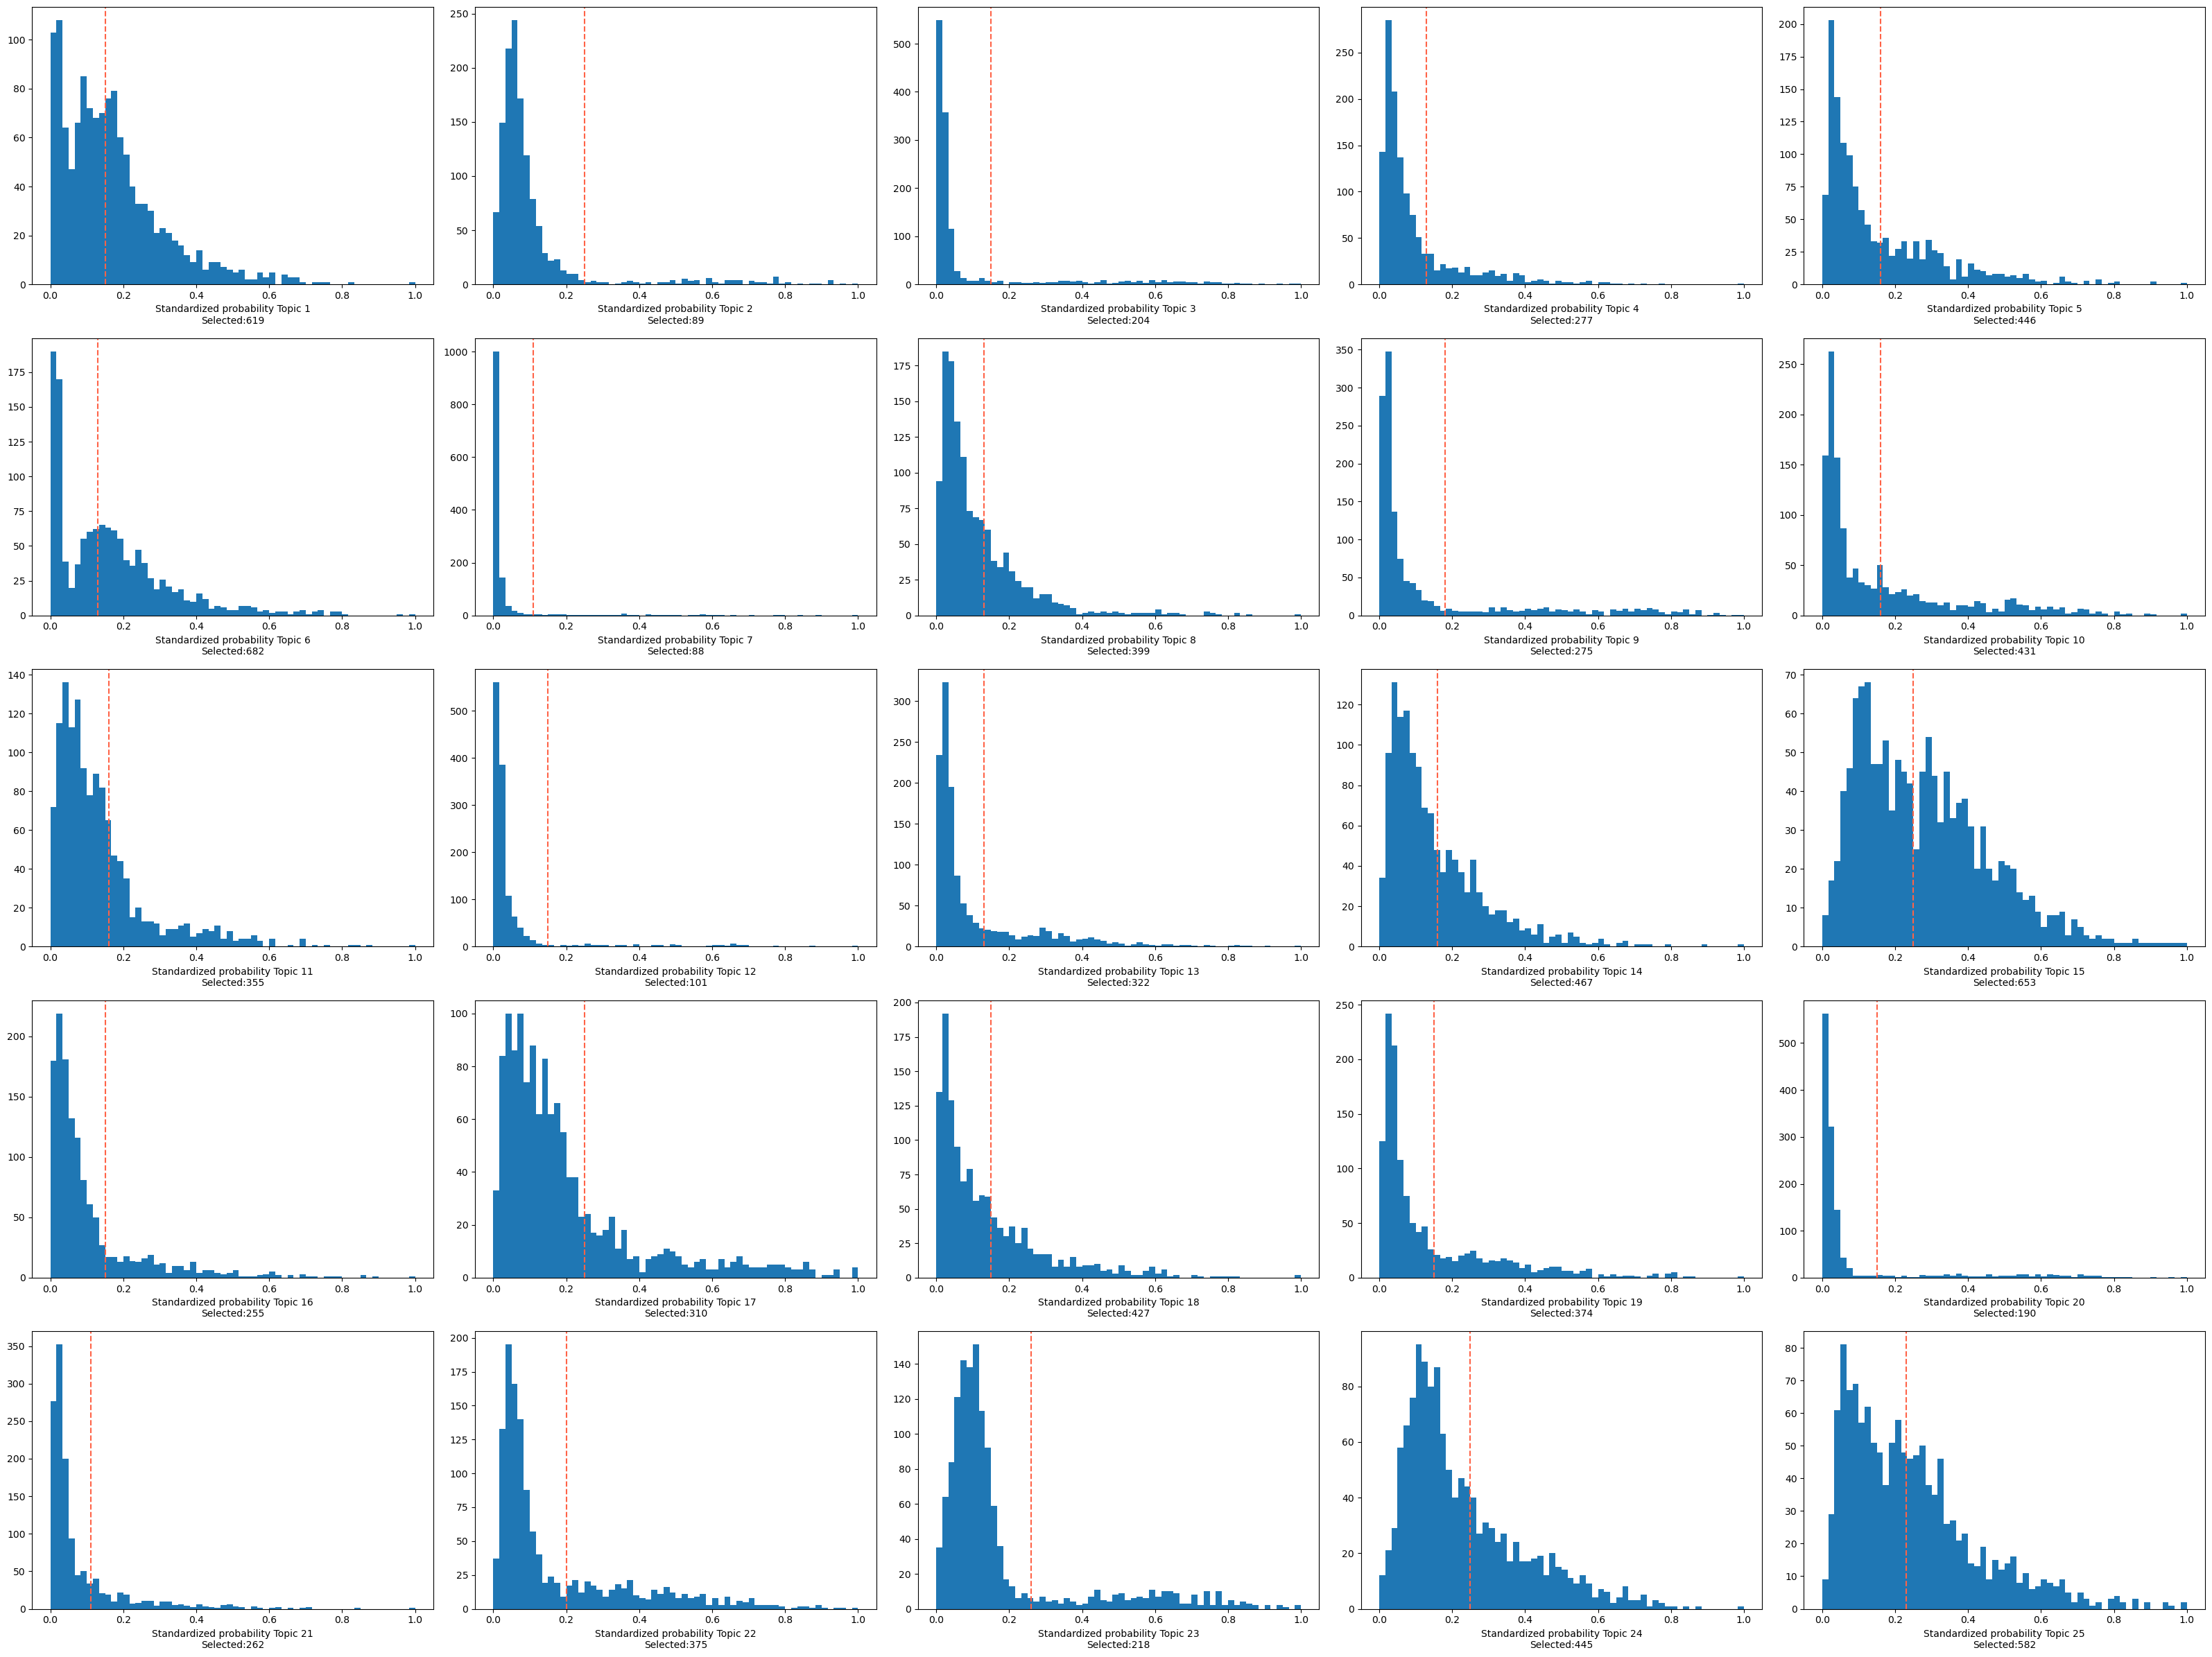

In [58]:
binarized_cell_topic = binarize_topics(cistopic_obj, target='cell', method='li', plot=True, num_columns=5, nbins=60)

In [59]:
from pycisTopic.topic_qc import *
topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [60]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

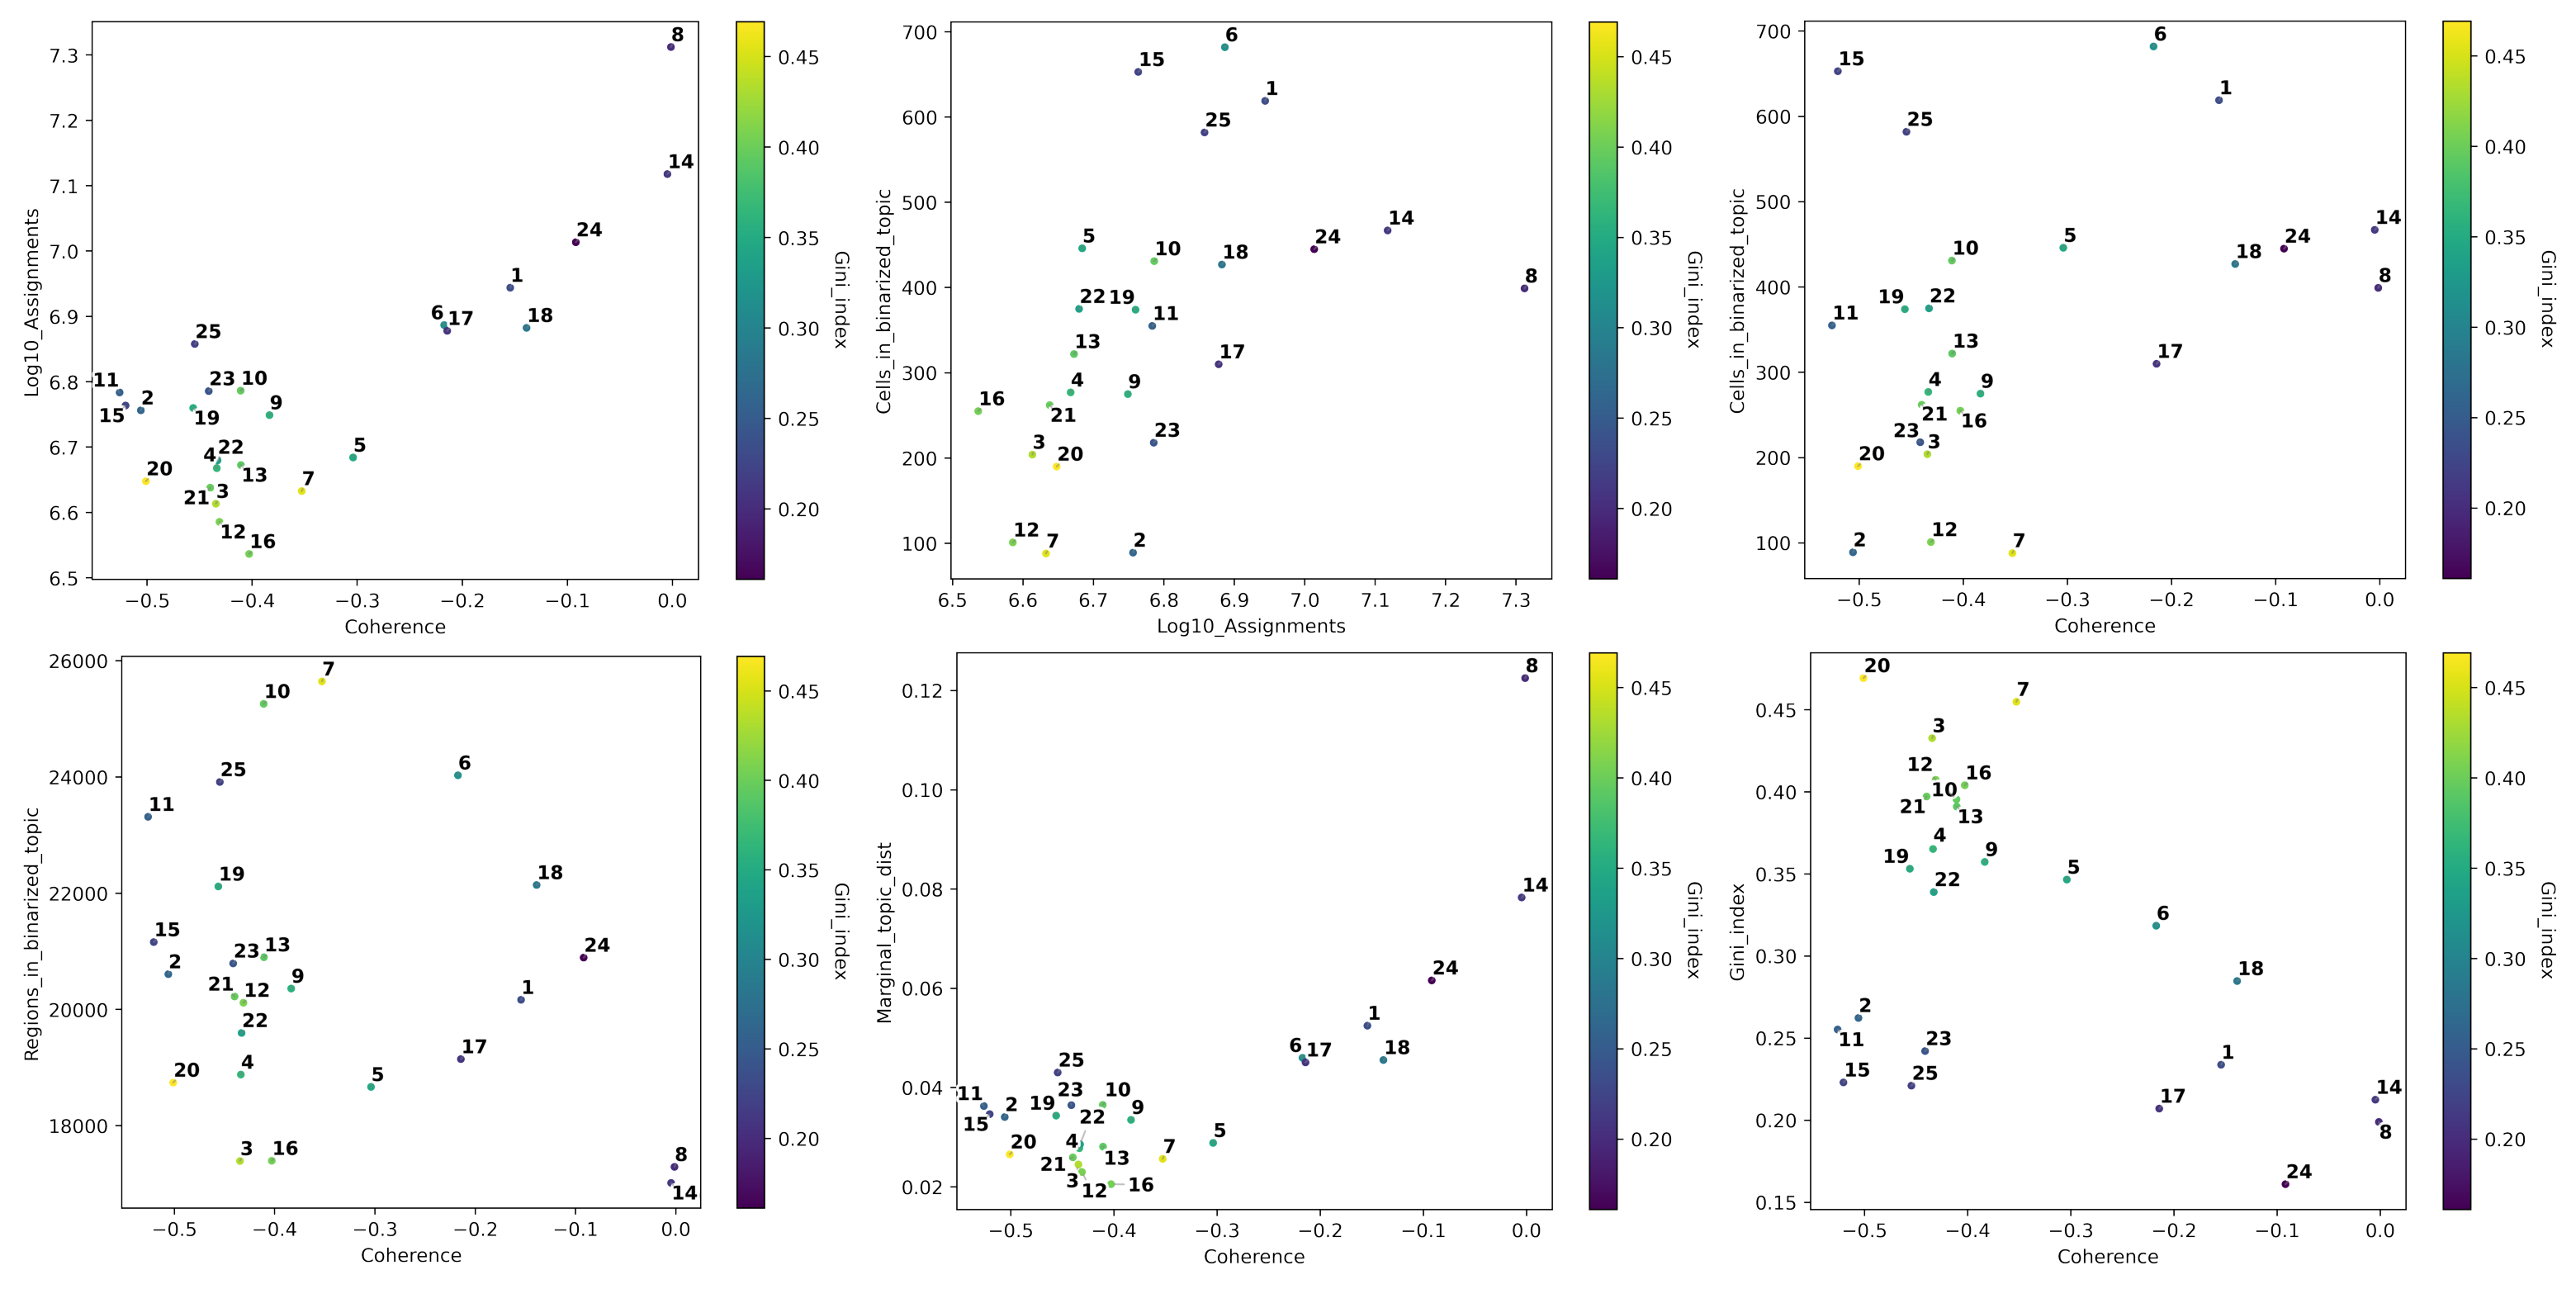

In [61]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
fig.savefig(outDir + 'topic_binarization/Topic_qc.pdf', bbox_inches='tight')
plt.show()

In [62]:
topic_annot = topic_annotation(cistopic_obj, annot_var='celltype', binarized_cell_topic=binarized_cell_topic, general_topic_thr = 0.2)

In [63]:
topic_annot

,celltype,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,"Rostral_neurectoderm, Paraxial_mesoderm, Eryth...",0.475422,0.141321,True
Topic2,"Endothelium, PGC",0.068356,0.015361,False
Topic3,"Haematoendothelial_progenitors, Primitive_Streak",0.156682,0.029186,False
Topic4,"Erythroid3, Spinal_cord",0.21275,0.040707,False
Topic5,"Erythroid3, Parietal_endoderm",0.34255,0.009217,True
Topic6,"Erythroid3, Neural_crest, Erythroid2",0.52381,0.036098,True
Topic7,,0.067588,0.0,False
Topic8,"Rostral_neurectoderm, Caudal_epiblast, Erythro...",0.306452,0.09831,True
Topic9,"PGC, Primitive_Streak",0.211214,0.011521,False
Topic10,,0.331029,0.0,True


In [64]:
topic_qc_metrics = pd.concat([topic_annot[['celltype', 'Ratio_cells_in_topic', 'Ratio_group_in_population']], topic_qc_metrics], axis=1)

In [65]:
topic_qc_metrics

,celltype,Ratio_cells_in_topic,Ratio_group_in_population,Log10_Assignments,Assignments,Regions_in_binarized_topic,Cells_in_binarized_topic,Coherence,Marginal_topic_dist,Gini_index
Topic1,"Rostral_neurectoderm, Paraxial_mesoderm, Eryth...",0.475422,0.141321,6.943856,8787311.0,20166,619,-0.154327,0.052477,0.233824
Topic2,"Endothelium, PGC",0.068356,0.015361,6.756246,5704870.0,20607,89,-0.505977,0.034075,0.262309
Topic3,"Haematoendothelial_progenitors, Primitive_Streak",0.156682,0.029186,6.613326,4105122.0,17393,204,-0.434524,0.024523,0.432752
Topic4,"Erythroid3, Spinal_cord",0.21275,0.040707,6.667691,4652546.0,18880,277,-0.433663,0.027793,0.365239
Topic5,"Erythroid3, Parietal_endoderm",0.34255,0.009217,6.684082,4831505.0,18668,446,-0.303919,0.028861,0.346596
Topic6,"Erythroid3, Neural_crest, Erythroid2",0.52381,0.036098,6.886665,7703092.0,24028,682,-0.217241,0.046004,0.318494
Topic7,,0.067588,0.0,6.632720,4292594.0,25643,88,-0.352841,0.025641,0.454880
Topic8,"Rostral_neurectoderm, Caudal_epiblast, Erythro...",0.306452,0.09831,7.312142,20518337.0,17292,399,-0.001365,0.122506,0.198973
Topic9,"PGC, Primitive_Streak",0.211214,0.011521,6.748918,5609424.0,20360,275,-0.383495,0.033504,0.357347
Topic10,,0.331029,0.0,6.786368,6114598.0,25257,431,-0.410942,0.036521,0.395499


In [66]:
# Save
with open(outDir + 'topic_binarization/Topic_qc_metrics_annot.pkl', 'wb') as f:
  pickle.dump(topic_qc_metrics, f)
with open(outDir + 'topic_binarization/binarized_cell_topic.pkl', 'wb') as f:
  pickle.dump(binarized_cell_topic, f)
with open(outDir + 'topic_binarization/binarized_topic_region.pkl', 'wb') as f:
  pickle.dump(region_bin_topics, f)

## 6. Differentially Accessible Regions (DARs)

In [67]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [68]:
from pycisTopic.diff_features import *
imputed_acc_obj = impute_accessibility(cistopic_obj, selected_cells=None, selected_regions=None, scale_factor=10**6)

2024-10-30 14:56:27,053 cisTopic     INFO     Imputing drop-outs
2024-10-30 14:56:27,765 cisTopic     INFO     Scaling
2024-10-30 14:56:28,312 cisTopic     INFO     Keep non zero rows
2024-10-30 14:56:29,062 cisTopic     INFO     Imputed accessibility sparsity: 0.04945671344864511
2024-10-30 14:56:29,063 cisTopic     INFO     Create CistopicImputedFeatures object
2024-10-30 14:56:29,063 cisTopic     INFO     Done!


In [69]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2024-10-30 14:56:29,066 cisTopic     INFO     Normalizing imputed data
2024-10-30 14:56:31,598 cisTopic     INFO     Done!


2024-10-30 14:56:37,286 cisTopic     INFO     Calculating mean
2024-10-30 14:56:37,540 cisTopic     INFO     Calculating variance


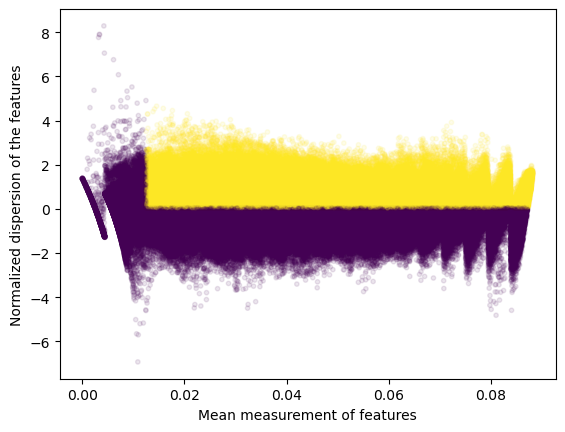

2024-10-30 14:56:56,075 cisTopic     INFO     Done!


In [70]:
os.mkdir(outDir+'DARs')
variable_regions = find_highly_variable_features(normalized_imputed_acc_obj,
                                           min_disp = 0.05,
                                           min_mean = 0.0125,
                                           max_mean = 3,
                                           max_disp = np.inf,
                                           n_bins=20,
                                           n_top_features=None,
                                           plot=True,
                                           save= outDir + 'DARs/HVR_plot.pdf')

In [71]:
len(variable_regions)

102495

In [78]:
markers_dict= find_diff_features(cistopic_obj,
                      imputed_acc_obj,
                      variable='pycisTopic_leiden_10_0.6',
                      var_features=variable_regions,
                      contrasts=None,
                      adjpval_thr=0.05,
                      log2fc_thr=np.log2(1.5),
                      n_cpu=5,
                      _temp_dir=tmpDir,
                      split_pattern = '-')

2024-10-30 15:25:02,532	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(markers_ray pid=223152) 2024-10-30 15:25:05,153 cisTopic     INFO     Formatting data for 0
(markers_ray pid=223153) 2024-10-30 15:25:05,252 cisTopic     INFO     Formatting data for 10
(markers_ray pid=223150) 2024-10-30 15:25:05,253 cisTopic     INFO     Formatting data for 1
(markers_ray pid=223151) 2024-10-30 15:25:05,337 cisTopic     INFO     Formatting data for 12
(markers_ray pid=223154) 2024-10-30 15:25:05,320 cisTopic     INFO     Formatting data for 11
(markers_ray pid=223152) 2024-10-30 15:25:06,191 cisTopic     INFO     Computing p-value for 0
(markers_ray pid=223153) 2024-10-30 15:25:06,244 cisTopic     INFO     Computing p-value for 10
(markers_ray pid=223150) 2024-10-30 15:25:06,266 cisTopic     INFO     Computing p-value for 1
(markers_ray pid=223151) 2024-10-30 15:25:06,286 cisTopic     INFO     Computing p-value for 12
(markers_ray pid=223154) 2024-10-30 15:25:06,308 cisTopic     INFO     Computing p-value for 11
(markers_ray pid=223150) 2024-10-30 15:25:45,122 cisTo

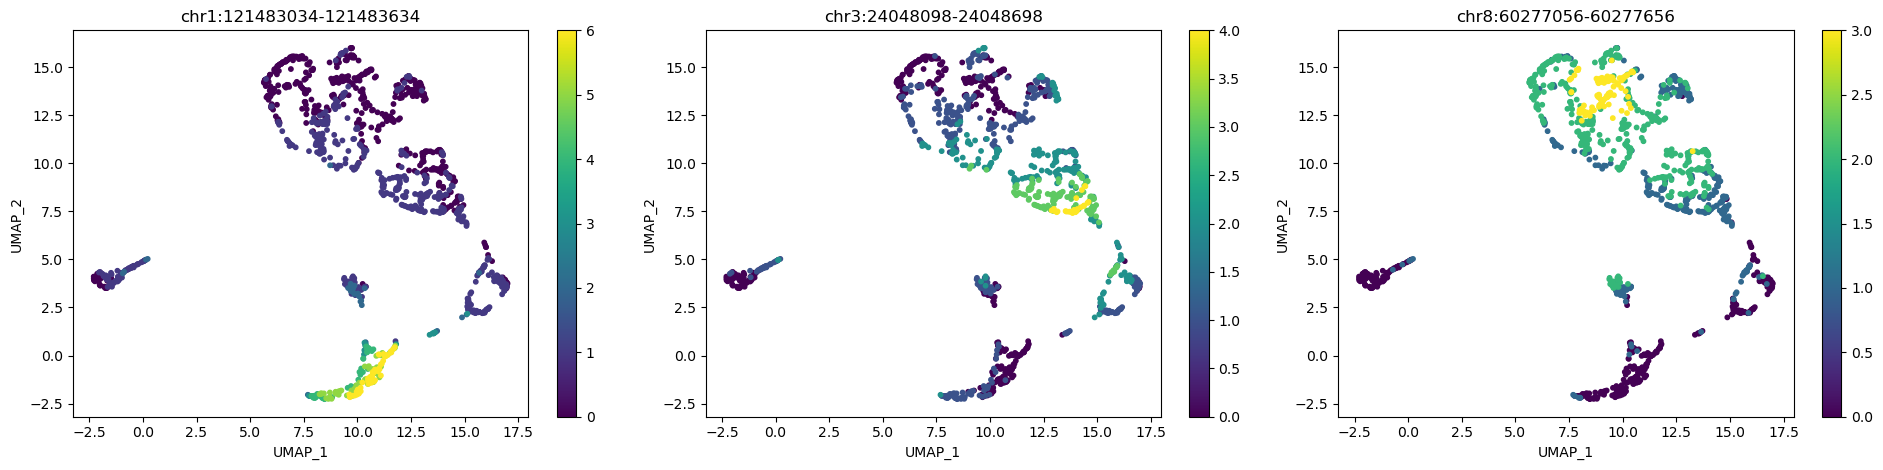

In [80]:
from pycisTopic.clust_vis import *
plot_imputed_features(cistopic_obj,
                    reduction_name='UMAP',
                    imputed_data=imputed_acc_obj,
                    features=[markers_dict[x].index.tolist()[0] for x in ['0', '1', '2']],
                    scale=False,
                    num_columns=4,
                    save= outDir + 'DARs/example_best_DARs.pdf')

In [81]:
x = [print(x + ': '+ str(len(markers_dict[x]))) for x in markers_dict.keys()]

0: 18120
1: 14206
10: 8003
11: 14661
12: 11553
13: 15649
14: 8747
2: 3505
3: 15413
4: 18624
5: 11483
6: 12710
7: 8
8: 14454
9: 10052


In [82]:
if not os.path.exists(os.path.join(work_dir, 'scATAC/candidate_enhancers')):
    os.makedirs(os.path.join(work_dir, 'scATAC/candidate_enhancers'))
import pickle
pickle.dump(markers_dict, open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'wb'))
pickle.dump(imputed_acc_obj, open(outDir + 'DARs/Imputed_accessibility.pkl', 'wb'))

# Motif enrichment analysis using pycistarget

In [1]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

# Project directory
projDir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus/'
# Output directory
outDir = projDir + 'pycistopic/'
import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
    
work_dir = outDir

In [2]:
import pickle
region_bin_topics_otsu = pickle.load(open(os.path.join(work_dir, 'topic_binarization/binarized_topic_region.pkl'), 'rb'))
#region_bin_topics_top3k = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/region_bin_topics_top3k.pkl'), 'rb'))
markers_dict = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'rb'))

In [3]:
import pyranges as pr
from pycistarget.utils import region_names_to_coordinates
region_sets = {}
region_sets['topics_otsu'] = {}
# region_sets['topics_top_3'] = {}
region_sets['DARs'] = {}
for topic in region_bin_topics_otsu.keys():
    regions = region_bin_topics_otsu[topic].index[region_bin_topics_otsu[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
    region_sets['topics_otsu'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
# for topic in region_bin_topics_top3k.keys():
#     regions = region_bin_topics_top3k[topic].index[region_bin_topics_top3k[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
#     region_sets['topics_top_3'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
for DAR in markers_dict.keys():
    regions = markers_dict[DAR].index[markers_dict[DAR].index.str.startswith('chr')] #only keep regions on known chromosomes
    region_sets['DARs'][DAR] = pr.PyRanges(region_names_to_coordinates(regions))

In [4]:
for key in region_sets.keys():
    print(f'{key}: {region_sets[key].keys()}')

topics_otsu: dict_keys(['Topic1', 'Topic2', 'Topic3', 'Topic4', 'Topic5', 'Topic6', 'Topic7', 'Topic8', 'Topic9', 'Topic10', 'Topic11', 'Topic12', 'Topic13', 'Topic14', 'Topic15', 'Topic16', 'Topic17', 'Topic18', 'Topic19', 'Topic20', 'Topic21', 'Topic22', 'Topic23', 'Topic24', 'Topic25'])
DARs: dict_keys(['0', '1', '10', '11', '12', '13', '14', '2', '3', '4', '5', '6', '7', '8', '9'])


In [5]:
db_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"
motif_annot_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"

In [6]:
rankings_db = os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.rankings.feather')
scores_db =  os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.scores.feather')
motif_annotation = os.path.join(motif_annot_fpath, 'motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl')

In [7]:
if not os.path.exists(os.path.join(work_dir, 'motifs')):
    os.makedirs(os.path.join(work_dir, 'motifs'))

In [8]:
from scenicplus.wrappers.run_pycistarget import run_pycistarget
run_pycistarget(
    region_sets = region_sets,
    species = 'mus_musculus',
    save_path = os.path.join(work_dir, 'motifs'),
    ctx_db_path = rankings_db,
    dem_db_path = scores_db,
    path_to_motif_annotations = motif_annotation,
    run_without_promoters = False,
    n_cpu = 1,
    _temp_dir = tmpDir,
    annotation_version = 'v10nr_clust',
    )

2024-10-30 16:59:09,652 pycisTarget_wrapper INFO     /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus/pycistopic/motifs folder already exists.
2024-10-30 16:59:10,336 pycisTarget_wrapper INFO     Loading cisTarget database for topics_otsu
2024-10-30 16:59:10,337 cisTarget    INFO     Reading cisTarget database
2024-10-30 17:00:36,024 pycisTarget_wrapper INFO     Running cisTarget for topics_otsu
2024-10-30 17:00:36,025 cisTarget    INFO     Running cisTarget for Topic1 which has 26129 regions
2024-10-30 17:00:45,720 cisTarget    INFO     Annotating motifs for Topic1
2024-10-30 17:00:48,293 cisTarget    INFO     Getting cistromes for Topic1
2024-10-30 17:00:48,533 cisTarget    INFO     Running cisTarget for Topic2 which has 20971 regions
2024-10-30 17:00:55,380 cisTarget    INFO     Annotating motifs for Topic2
2024-10-30 17:00:57,455 cisTarget    INFO     Getting cistromes for Topic2
2024-10-30 17:00:57,746 cisTarget    INFO     Running 

KeyError: 'Chromosome'

In [ ]:
import dill
menr = dill.load(open(os.path.join(work_dir, 'motifs/menr.pkl'), 'rb'))